### Dataset definition

In [1]:
import torch
import glob
import pickle
from enum import IntEnum
from torch.utils.data import Dataset

class CollisionLabel(IntEnum):
    SAFE = 0
    WARNING = 1
    CRITICAL = 2

class CollisionDataset(Dataset):
    def __init__(self, root_dir, mode, window_size=None, transform=None):
        self.root_dir = root_dir
        self.mode = mode
        self.window_size = window_size
        self.transform = transform

        self.data = []
        self.labels = []
        self.subject_indices = {}

        current_idx = 0
        samples_dir = os.path.join(root_dir, 'samples')
        subjects = sorted([d for d in os.listdir(samples_dir) if os.path.isdir(os.path.join(samples_dir, d))])

        for subj in subjects:
            self.subject_indices[subj] = []
            subj_sample_path = os.path.join(samples_dir, subj)
            label_type = 'static' if mode == 'static' else 'dynamic'
            subj_label_path = os.path.join(root_dir, 'labels', label_type, subj)
            pkl_files = sorted(glob.glob(os.path.join(subj_sample_path, '*.pkl')))

            for pkl_f in pkl_files:
                file_name_no_ext = os.path.splitext(os.path.basename(pkl_f))[0]
                label_name = f"{file_name_no_ext}_labels.npy"
                npy_f = os.path.join(subj_label_path, label_name)

                if not os.path.exists(npy_f):
                    raise FileNotFoundError(f"Could not load label: {npy_f}")

                with open(pkl_f, 'rb') as f:
                    raw_data = pickle.load(f)

                human_seq = np.array([frame[0] for frame in raw_data])
                robot_seq = np.array([frame[1] for frame in raw_data])
                human_flat = human_seq.reshape(human_seq.shape[0], -1)
                robot_flat = robot_seq.reshape(robot_seq.shape[0], -1)
                features = np.concatenate((human_flat, robot_flat), axis=1)

                targets = np.load(npy_f)
                num_frames = features.shape[0]

                if self.mode == 'static':
                    for i in range(num_frames):
                        self.data.append(features[i])
                        self.labels.append(targets[i])
                        self.subject_indices[subj].append(current_idx)
                        current_idx += 1

                elif self.mode == 'dynamic':
                    if window_size is None:
                        raise ValueError("Parameter window_size is required for dynamic mode")

                    for i in range(num_frames):
                        start_idx = i - window_size + 1

                        if start_idx < 0:
                            real_data = features[0 : i + 1]
                            missing_count = window_size - real_data.shape[0]
                            padding = np.tile(features[0], (missing_count, 1))
                            window_x = np.concatenate((padding, real_data), axis=0)
                        else:
                            window_x = features[start_idx : i + 1]

                        self.data.append(window_x)
                        self.labels.append(targets[i])
                        self.subject_indices[subj].append(current_idx)
                        current_idx += 1

        self.data = np.array(self.data)
        self.labels = np.array(self.labels)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = torch.tensor(self.data[idx], dtype=torch.float32)
        y = torch.tensor(self.labels[idx], dtype=torch.long)

        if self.transform is not None:
            x = self.transform(x)

        return x, y

    def get_indices_for_subjects(self, subject_list):
        indices = []
        for subj in subject_list:
            if subj in self.subject_indices:
                indices.extend(self.subject_indices[subj])
        return indices

    def get_stats(self):
        return np.mean(self.data, axis=0), np.std(self.data, axis=0)

### Data augmentation tools

In [2]:
class TransformedSubset(Dataset):
    """Wrapper for dynamically applying transforms to Subset objects"""

    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, idx):
        x, y = self.subset[idx]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)


class GaussianNoise(object):
    """Adds gaussian noise to samples for data augmentation."""

    def __init__(self, mean=0., std=0.01):
        self.std = std
        self.mean = mean

    def __call__(self, tensor):
        return tensor + torch.randn(tensor.size()) * self.std + self.mean

    def __repr__(self):
        return f"{self.__class__.__name__}(mean={self.mean}, std={self.std})"


class Normalize(object):
    """Performs Z-Score normalization."""

    def __init__(self, mean, std):
        self.mean = torch.tensor(mean, dtype=torch.float32)
        self.std = torch.tensor(std, dtype=torch.float32)

        #Avoids zero division
        self.std = torch.clamp(torch.tensor(std, dtype=torch.float32), min=1e-7)

    def __call__(self, tensor):
        return (tensor - self.mean) / self.std

### Trainer definition

In [3]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Subset, DataLoader
from sklearn.metrics import classification_report
import copy
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

class Trainer:
    def __init__(self,
             model: nn.Module,
             loaders: dict,
             device=None,
             loss_criterion=nn.CrossEntropyLoss(),
             optimizer_cls=optim.Adam,
             optimizer_kwargs=None
        ):

        if device is not None:
            self.device = device
        else:
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        print(f"Trainer initialized on device: {self.device}")

        self.model = model.to(self.device)
        self.loaders = loaders
        self.criterion = loss_criterion.to(self.device)
        self.optimizer_cls = optimizer_cls
        self.optimizer_kwargs = optimizer_kwargs if optimizer_kwargs else {}

    def train(self, num_epochs=1, learning_rate=0.001, patience=10, use_scheduler=True, checkpoint_path='best_model.pth', load_checkpoint: bool=False, checkpoint_interval=5):
        optimizer = self.optimizer_cls(self.model.parameters(), lr=learning_rate, **self.optimizer_kwargs)

        scheduler = None
        if use_scheduler:
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

        if load_checkpoint:
            if os.path.isfile(checkpoint_path):
                self.model.load_state_dict(torch.load(checkpoint_path, self.device))
                print('Loaded model checkpoint.')

        history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
        best_val_loss = float('inf')
        patience_counter = 0
        best_model_wts = copy.deepcopy(self.model.state_dict())

        for epoch in range(num_epochs):
            self.model.train()
            t_loss, t_corr, t_total = 0.0, 0, 0

            for inputs, labels in self.loaders['train']:
                inputs, labels = inputs.to(self.device), labels.to(self.device)

                optimizer.zero_grad()
                outputs = self.model(inputs)
                loss = self.criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                t_loss += loss.item() * inputs.size(0)
                _, pred = torch.max(outputs, 1)
                t_total += labels.size(0)
                t_corr += (pred == labels).sum().item()

            epoch_t_loss = t_loss / t_total
            epoch_t_acc = t_corr / t_total

            self.model.eval()
            v_loss, v_corr, v_total = 0.0, 0, 0
            with torch.no_grad():
                for inputs, labels in self.loaders['validation']:
                    inputs, labels = inputs.to(self.device), labels.to(self.device)
                    outputs = self.model(inputs)
                    loss = self.criterion(outputs, labels)

                    v_loss += loss.item() * inputs.size(0)
                    _, pred = torch.max(outputs, 1)
                    v_total += labels.size(0)
                    v_corr += (pred == labels).sum().item()

            epoch_v_loss = v_loss / v_total
            epoch_v_acc = v_corr / v_total

            history['train_loss'].append(epoch_t_loss)
            history['train_acc'].append(epoch_t_acc)
            history['val_loss'].append(epoch_v_loss)
            history['val_acc'].append(epoch_v_acc)

            print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_t_loss:.4f} Acc: {epoch_t_acc*100:.2f}% | Val Loss: {epoch_v_loss:.4f} Acc: {epoch_v_acc*100:.2f}%")

            if use_scheduler:
                scheduler.step(epoch_v_loss)

            if epoch % checkpoint_interval == checkpoint_interval-1:
                if epoch_v_loss < best_val_loss:
                    best_val_loss = epoch_v_loss
                    patience_counter = 0
                    torch.save(self.model.state_dict(), checkpoint_path)
                    best_model_wts = copy.deepcopy(self.model.state_dict())
                    torch.save(best_model_wts, checkpoint_path)
                    print("  -> Model Saved")
                else:
                    patience_counter += 1
                    if patience_counter >= patience:
                        print("Early Stopping Triggered.")
                        break


        print("\nLoading Best Model for Final Testing...")
        self.model.load_state_dict(best_model_wts)

        self.evaluate_test()

        print("--- HISTORY ---")

        print('Train loss:')
        for epoch, val in enumerate(history['train_loss']):
            print(f"\tEpoch {epoch} | {val:.3f}")

        print('Train accuracy:')
        for epoch, val in enumerate(history['train_acc']):
            print(f"\tEpoch {epoch} | {val*100:.3}%")

        print('Validation loss:')
        for epoch, val in enumerate(history['val_loss']):
            print(f"\tEpoch {epoch} | {val:.3f}")

        print('Validation accuracy:')
        for epoch, val in enumerate(history['val_acc']):
            print(f"\tEpoch {epoch} | {val*100:.3}%")

    def evaluate_test(self):
        self.model.eval()
        all_preds = []
        all_labels = []

        with (torch.no_grad()):
            for inputs, labels in self.loaders['test']:
                inputs = inputs.to(self.device)
                labels = labels.to(self.device)
                outputs = self.model(inputs)
                _, preds = torch.max(outputs, 1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        print("--- TEST REPORT ---")
        target_names = ['SAFE', 'WARNING', 'CRITICAL']
        print(classification_report(all_labels, all_preds, target_names=target_names, zero_division=0))

        self._plot_confusion_matrix(all_labels, all_preds, classes=target_names, normalize=False)

    @staticmethod
    def _plot_confusion_matrix(y_true, y_pred, classes, normalize=False, title='Confusion Matrix'):
        cm = confusion_matrix(y_true, y_pred)

        if normalize:
            cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
            fmt = '.2f'
        else:
            fmt = 'd'

        plt.figure(figsize=(8, 6))
        sns.set_theme(font_scale=1.2)
        sns.heatmap(cm, annot=True, fmt=fmt, cmap='Blues',
                    xticklabels=classes, yticklabels=classes,
                    linewidths=.5, linecolor='gray')

        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.title(title, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.show()

### Phase 1: Frame-by-frame safety classifier

In [4]:
class StaticSafetyClassifier(nn.Module):
    def __init__(self, input_dimension, num_classes, train_mean, train_std):
        super().__init__()

        self.train_mean = train_mean
        self.train_std = train_std

        self.backbone = nn.Sequential(
            self._block(input_dimension, 128),
            self._block(128, 64),
            self._block(64, 32)
        )
        self._head = nn.Linear(32, num_classes)

    def forward(self, x):
        x = self.backbone(x)
        x = self._head(x)
        return x

    def infer(self, x):
        self.eval()
        device = next(self.parameters()).device

        with torch.no_grad():
            x = (torch.tensor(x, dtype=torch.float32) - torch.tensor(self.train_mean, dtype=torch.float32)) / (torch.tensor(self.train_std, dtype=torch.float32) + 1e-7)
            x = x.unsqueeze(0).to(device)

            output = self(x)
            prediction = torch.argmax(output, dim=1).item()
        return prediction

    @staticmethod
    def _block(in_f, out_f, dropout = 0.2):
            return nn.Sequential(
                nn.Linear(in_f, out_f),
                nn.BatchNorm1d(out_f),
                nn.ReLU(),
                nn.Dropout(dropout)
            )

In [5]:
from sklearn.utils.class_weight import compute_class_weight
import torch.nn as nn
from torchvision import transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 128
TRAIN_SPLIT = 0.7
VALIDATION_SPLIT = 0.15

"""_____ STATIC DATASET _____"""

static_dataset = CollisionDataset(
    root_dir = '../dataset/',
    mode = 'static'
)
input_dim = static_dataset[0][0].shape[0]
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(static_dataset.labels),
    y=static_dataset.labels
)
static_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f"Computed weights: {static_weights_tensor}")

static_criterion = nn.CrossEntropyLoss(weight=static_weights_tensor)
all_subjects = sorted(list(static_dataset.subject_indices.keys()))

np.random.shuffle(all_subjects)

num_subjects = len(all_subjects)
train_end = int(num_subjects * TRAIN_SPLIT)
val_end = int(num_subjects * (TRAIN_SPLIT + VALIDATION_SPLIT))

train_subjs = all_subjects[:train_end]
val_subjs = all_subjects[train_end:val_end]
test_subjs = all_subjects[val_end:]

print(f"Split:\n\tTrain: {train_subjs}\n\tValidation: {val_subjs}\n\tTest: {test_subjs}")

train_idx = static_dataset.get_indices_for_subjects(train_subjs)
val_idx = static_dataset.get_indices_for_subjects(val_subjs)
test_idx = static_dataset.get_indices_for_subjects(test_subjs)

train_data_raw = static_dataset.data[train_idx]
static_mean = np.mean(train_data_raw, axis=0)
static_std = np.std(train_data_raw, axis=0)

train_transforms = transforms.Compose([
    Normalize(mean=static_mean, std=static_std),
    GaussianNoise(0, 0.05)
])

eval_transforms = transforms.Compose([
    Normalize(mean=static_mean, std=static_std)
])

train_subset = TransformedSubset(
    Subset(static_dataset, train_idx),
    train_transforms
)
val_subset = TransformedSubset(
    Subset(static_dataset, val_idx),
    eval_transforms
)
test_subset = TransformedSubset(
    Subset(static_dataset, test_idx),
    eval_transforms
)

loaders = {
    'train': DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True),
    'validation': DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False),
    'test': DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False)
}

static_classifier = StaticSafetyClassifier(input_dim, len(CollisionLabel))

static_trainer = Trainer(
    static_classifier,
    loaders,
    device = device,
    loss_criterion = static_criterion,
    shuffle_subjects = True
)

Computed weights: tensor([ 0.3718,  3.3607, 78.7697], device='cuda:0')
Split:
	Train: ['S08', 'S10', 'S12', 'S06', 'S16', 'S11', 'S15', 'S02', 'S01', 'S19', 'S09', 'S14', 'S03', 'S17']
	Validation: ['S18', 'S13', 'S04']
	Test: ['S05', 'S07', 'S00']
Trainer initialized on device: cuda


Epoch 1/35 | Train Loss: 0.4968 Acc: 85.38% | Val Loss: 0.2727 Acc: 86.85%
Epoch 2/35 | Train Loss: 0.3345 Acc: 89.40% | Val Loss: 0.1897 Acc: 91.85%
Epoch 3/35 | Train Loss: 0.3015 Acc: 90.43% | Val Loss: 0.2093 Acc: 90.66%
Epoch 4/35 | Train Loss: 0.2784 Acc: 91.22% | Val Loss: 0.1475 Acc: 94.27%
Epoch 5/35 | Train Loss: 0.2631 Acc: 91.72% | Val Loss: 0.1645 Acc: 93.03%
  -> Model Saved
Epoch 6/35 | Train Loss: 0.2445 Acc: 91.99% | Val Loss: 0.1670 Acc: 92.43%
Epoch 7/35 | Train Loss: 0.2428 Acc: 92.24% | Val Loss: 0.1765 Acc: 93.04%
Epoch 8/35 | Train Loss: 0.2297 Acc: 92.40% | Val Loss: 0.1563 Acc: 94.38%
Epoch 9/35 | Train Loss: 0.2003 Acc: 93.24% | Val Loss: 0.1384 Acc: 94.90%
Epoch 10/35 | Train Loss: 0.1888 Acc: 93.38% | Val Loss: 0.1410 Acc: 94.24%
  -> Model Saved
Epoch 11/35 | Train Loss: 0.1857 Acc: 93.45% | Val Loss: 0.1321 Acc: 95.01%
Epoch 12/35 | Train Loss: 0.1767 Acc: 93.77% | Val Loss: 0.1380 Acc: 94.25%
Epoch 13/35 | Train Loss: 0.1806 Acc: 93.73% | Val Loss: 0.1364

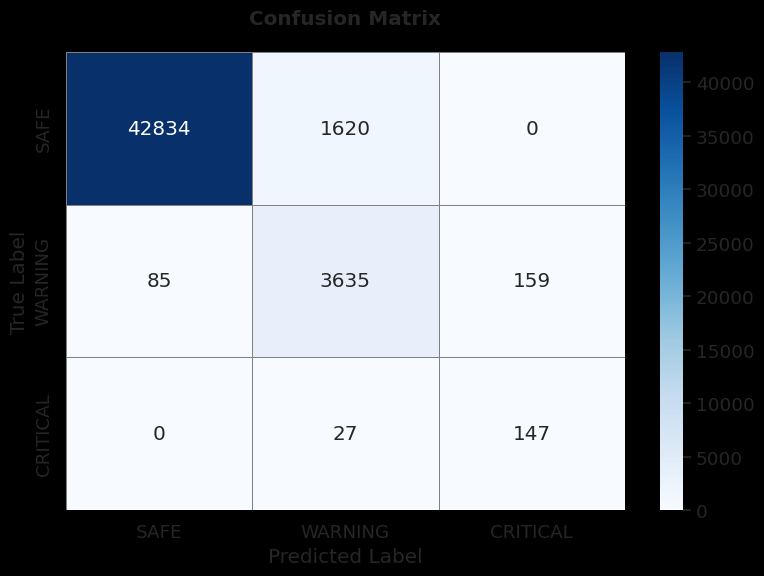

--- HISTORY ---
Train loss:
	Epoch 0 | 0.497
	Epoch 1 | 0.334
	Epoch 2 | 0.302
	Epoch 3 | 0.278
	Epoch 4 | 0.263
	Epoch 5 | 0.245
	Epoch 6 | 0.243
	Epoch 7 | 0.230
	Epoch 8 | 0.200
	Epoch 9 | 0.189
	Epoch 10 | 0.186
	Epoch 11 | 0.177
	Epoch 12 | 0.181
	Epoch 13 | 0.175
	Epoch 14 | 0.171
	Epoch 15 | 0.175
	Epoch 16 | 0.169
	Epoch 17 | 0.167
	Epoch 18 | 0.171
	Epoch 19 | 0.168
	Epoch 20 | 0.172
	Epoch 21 | 0.173
	Epoch 22 | 0.171
	Epoch 23 | 0.173
	Epoch 24 | 0.170
	Epoch 25 | 0.170
	Epoch 26 | 0.168
	Epoch 27 | 0.164
	Epoch 28 | 0.166
	Epoch 29 | 0.166
	Epoch 30 | 0.172
	Epoch 31 | 0.168
	Epoch 32 | 0.175
	Epoch 33 | 0.170
	Epoch 34 | 0.170
Train accuracy:
	Epoch 0 | 85.4%
	Epoch 1 | 89.4%
	Epoch 2 | 90.4%
	Epoch 3 | 91.2%
	Epoch 4 | 91.7%
	Epoch 5 | 92.0%
	Epoch 6 | 92.2%
	Epoch 7 | 92.4%
	Epoch 8 | 93.2%
	Epoch 9 | 93.4%
	Epoch 10 | 93.4%
	Epoch 11 | 93.8%
	Epoch 12 | 93.7%
	Epoch 13 | 93.8%
	Epoch 14 | 93.8%
	Epoch 15 | 93.8%
	Epoch 16 | 93.9%
	Epoch 17 | 93.9%
	Epoch 18 | 93.9%
	Epo

In [6]:
static_trainer.train(num_epochs=35, patience=3, load_checkpoint=True, checkpoint_interval=5)